In [4]:
import scanpy as sc
import pandas as pd

adata_dr = sc.read_h5ad("GSM4878207_GSM4878210_adypose.h5ad")

## Step 1 — Browse available pathway libraries and find your pathway
Use `browse_pathways()` to preview what's available **before** running the pipeline.

In [7]:
adata_dr.layers["counts"] = adata_dr.X.copy()
# Normalizing to median total counts
sc.pp.normalize_total(adata_dr)
# Logarithmize the data
sc.pp.log1p(adata_dr)

adata_dr

AnnData object with n_obs × n_vars = 2540 × 13281
    obs: 'cell_type', 'batch_id', 'cluster'
    uns: 'log1p'
    obsm: 'X_umap'
    layers: 'counts'

c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\preprocessing\_pca.py:206: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('anndata')` instead.
  Version(ad.__version__) < Version("0.9")
c:\Users\selim\miniconda3\envs\scanpy_env_311\Lib\site-packages\scanpy\neighbors\__init__.py:423: FutureWarning: Use obsm (e.g. `k in adata.obsm` or `adata.obsm.keys() | {'u'}`) instead of AnnData.obsm_keys, AnnData.obsm_keys is deprecated and will be removed in the future.
  if "X_diffmap" in adata.obsm_keys():


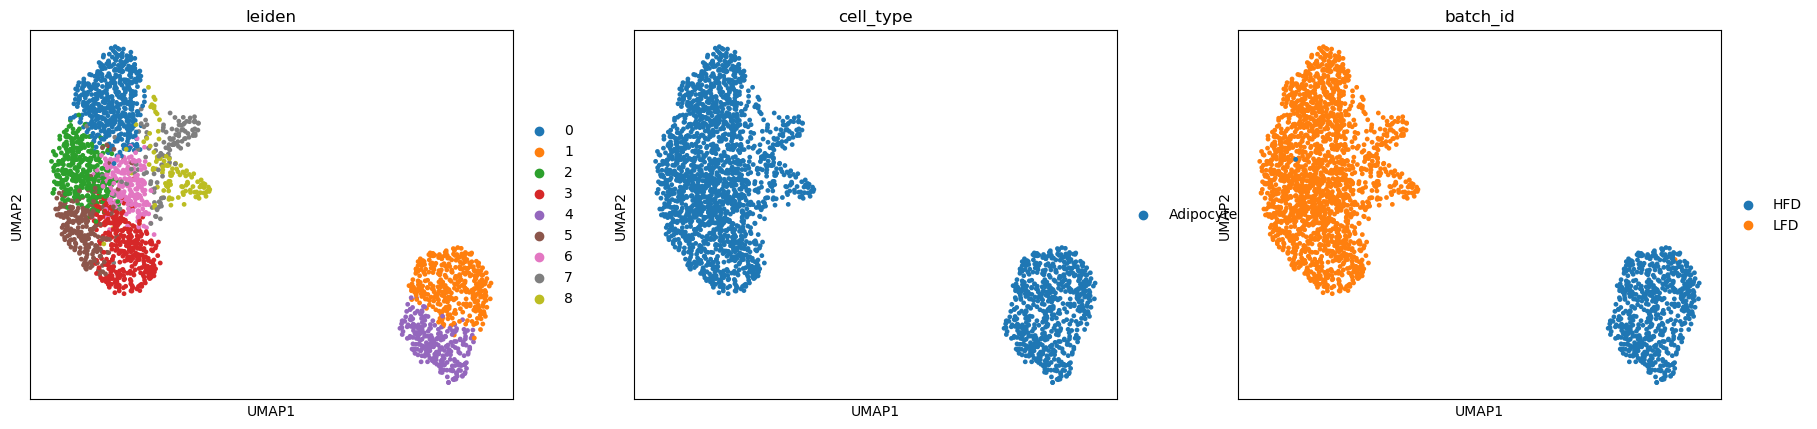

In [9]:
# process to visualize
sc.pp.highly_variable_genes(adata_dr, n_top_genes=2000)
sc.tl.pca(adata_dr, n_comps=50, svd_solver="arpack")
sc.pp.neighbors(adata_dr, n_neighbors=15)
sc.tl.umap(adata_dr, n_components=2)
sc.tl.leiden(adata_dr, flavor="leidenalg", n_iterations=2, resolution=1.0)

# Using the igraph implementation and a fixed number of iterations can be significantly faster,
# especially for larger datasets
sc.pl.umap(adata_dr, color=["leiden", "cell_type", "batch_id"])


In [10]:
from qubo_dr.pathway import browse_pathways, preview_pathway_genes, list_enrichr_libraries

# ── List available libraries (filter by keyword) ───────────────────────────
print("=== Libraries containing 'KEGG' ===")
print(list_enrichr_libraries('KEGG'))

print("\n=== Libraries containing 'GO_Biological' ===")
print(list_enrichr_libraries('GO_Biological'))

print("\n=== Libraries containing 'Reactome' ===")
print(list_enrichr_libraries('Reactome'))

print("\n=== Libraries containing 'GO_Molecular_Function' ===")
print(list_enrichr_libraries('GO_Molecular_Function'))

=== Libraries containing 'KEGG' ===
['KEGG_2013', 'KEGG_2015', 'KEGG_2016', 'KEGG_2019_Human', 'KEGG_2019_Mouse', 'KEGG_2021_Human', 'KEGG_2026']

=== Libraries containing 'GO_Biological' ===
['GO_Biological_Process_2021', 'GO_Biological_Process_2023', 'GO_Biological_Process_2025', 'GO_Biological_Process_2026']

=== Libraries containing 'Reactome' ===
['Reactome_2022', 'Reactome_Pathways_2024']

=== Libraries containing 'GO_Molecular_Function' ===
['GO_Molecular_Function_2021', 'GO_Molecular_Function_2023', 'GO_Molecular_Function_2025', 'GO_Molecular_Function_2026']


In [11]:
# ── Browse via Enrichr libraries (offline, no rate limit) ─────────────────
browse_pathways('PPAR', organism='human', libraries=['KEGG_2026'], 
                show_genes=True, max_results=20)


[KEGG_2026  —  matches for 'PPAR']
  [  76 genes]  PPAR SIGNALING PATHWAY
             → UBC, FABP4, PDPK1, SLC27A1, SLC27A4, RXRB, PCK2, ACOX1, ACSBG2, ACSL3 ...

→ 1 total match(es) across 1 librar(ies).
  Copy the exact term name and pass it to get_pathway_genes() or preview_pathway_genes()
  Optionally add library='<library name>' once you know which database to use.


{'KEGG_2026': {'PPAR SIGNALING PATHWAY': ['UBC',
   'FABP4',
   'PDPK1',
   'SLC27A1',
   'SLC27A4',
   'RXRB',
   'PCK2',
   'ACOX1',
   'ACSBG2',
   'ACSL3',
   'FABP7',
   'GK',
   'NR1H3',
   'PCK1',
   'EHHADH',
   'ACSBG1',
   'FABP1',
   'FABP3',
   'HMGCS1',
   'PLIN2',
   'PLIN1',
   'PLIN4',
   'PPARA',
   'ACOX2',
   'FABP5',
   'PPARG',
   'ACOX3',
   'MMP1',
   'OLR1',
   'CPT2',
   'AQP7B',
   'ACSL6',
   'PLTP',
   'SCD',
   'SCD5',
   'CPT1A',
   'SYCP2',
   'HMGCS2',
   'ADIPOQ',
   'ANGPTL4',
   'APOA1',
   'APOC3',
   'SLC27A2',
   'FADS2',
   'GK3',
   'ACSL4',
   'ACAA1',
   'CPT1B',
   'CYP7A1',
   'DBI',
   'GK2',
   'CPT1C',
   'APOA2',
   'ACSL5',
   'CYP27A1',
   'LPL',
   'PPARD',
   'RXRA',
   'APOA5',
   'ACADL',
   'CYP8B1',
   'FABP2',
   'PLIN5',
   'SLC27A5',
   'SLC27A6',
   'CD36',
   'ILK',
   'ACADM',
   'PCDHGA5',
   'SORBS1',
   'AQP7',
   'RXRG',
   'ACSL1',
   'PCDHB16',
   'FABP6',
   'UCP1']}}

In [19]:
# ── Preview the full gene list for a specific pathway ─────────────────────
pathway_target = 'PPAR SIGNALING PATHWAY'
pathway_genes = preview_pathway_genes(pathway_target, organism='mouse', library='KEGG_2026')
print(f"\nTotal: {len(pathway_genes)} genes")

  Found 'PPAR SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 76

[KEGG_2026  —  'PPAR SIGNALING PATHWAY']  76 genes:
  UBC         FABP4       PDPK1       SLC27A1     SLC27A4     RXRB      
  PCK2        ACOX1       ACSBG2      ACSL3       FABP7       GK        
  NR1H3       PCK1        EHHADH      ACSBG1      FABP1       FABP3     
  HMGCS1      PLIN2       PLIN1       PLIN4       PPARA       ACOX2     
  FABP5       PPARG       ACOX3       MMP1        OLR1        CPT2      
  AQP7B       ACSL6       PLTP        SCD         SCD5        CPT1A     
  SYCP2       HMGCS2      ADIPOQ      ANGPTL4     APOA1       APOC3     
  SLC27A2     FADS2       GK3         ACSL4       ACAA1       CPT1B     
  CYP7A1      DBI         GK2         CPT1C       APOA2       ACSL5     
  CYP27A1     LPL         PPARD       RXRA        APOA5       ACADL     
  CYP8B1      FABP2       PLIN5       SLC27A5     SLC27A6     CD36      
  ILK         ACADM       PCDHGA5     SORBS1      AQP7        RXRG      
 

In [14]:
from pprint import pprint
pprint(pathway_genes, compact=True, width=177)

['UBC', 'FABP4', 'PDPK1', 'SLC27A1', 'SLC27A4', 'RXRB', 'PCK2', 'ACOX1', 'ACSBG2', 'ACSL3', 'FABP7', 'GK', 'NR1H3', 'PCK1', 'EHHADH', 'ACSBG1', 'FABP1', 'FABP3', 'HMGCS1',
 'PLIN2', 'PLIN1', 'PLIN4', 'PPARA', 'ACOX2', 'FABP5', 'PPARG', 'ACOX3', 'MMP1', 'OLR1', 'CPT2', 'AQP7B', 'ACSL6', 'PLTP', 'SCD', 'SCD5', 'CPT1A', 'SYCP2', 'HMGCS2', 'ADIPOQ',
 'ANGPTL4', 'APOA1', 'APOC3', 'SLC27A2', 'FADS2', 'GK3', 'ACSL4', 'ACAA1', 'CPT1B', 'CYP7A1', 'DBI', 'GK2', 'CPT1C', 'APOA2', 'ACSL5', 'CYP27A1', 'LPL', 'PPARD', 'RXRA',
 'APOA5', 'ACADL', 'CYP8B1', 'FABP2', 'PLIN5', 'SLC27A5', 'SLC27A6', 'CD36', 'ILK', 'ACADM', 'PCDHGA5', 'SORBS1', 'AQP7', 'RXRG', 'ACSL1', 'PCDHB16', 'FABP6', 'UCP1']


## Step 2 — Run DR-QUBO on Kong2023 (Crohn's disease) stem cells

In [15]:
adata_dr

AnnData object with n_obs × n_vars = 2540 × 13281
    obs: 'cell_type', 'batch_id', 'cluster', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors', 'batch_id_colors'
    obsm: 'X_umap', 'X_pca'
    varm: 'PCs'
    layers: 'counts'
    obsp: 'distances', 'connectivities'

In [16]:
import numpy as np
from scipy.sparse import issparse
from qubo_dr.pipeline import run_pipeline
from qubo_dr.pathway import preview_pathway_genes

# Extract matrix and gene symbols
# Note: var_names in this dataset are Ensembl IDs — use var['gene_symbols'] for pathway matching
# For datasets where var_names ARE already gene symbols, use: g_cd = list(adata_dr.var_names)
X_cd     = adata_dr.X.toarray().T if issparse(adata_dr.X) else adata_dr.X.T  # → genes × cells
g_cd     = list(adata_dr.var_names)
batch_cd = adata_dr.obs['batch_id'].values  
test_label = 'HFD'
reference_label = 'LFD' 

print(f"Adypocyte diet study: {(batch_cd == test_label).sum()} | WT control: {(batch_cd == reference_label).sum()}")
print(f"Matrix shape (genes × cells): {X_cd.shape}")
print(f"Gene name example: {g_cd[:5]}")

Adypocyte diet study: 641 | WT control: 1899
Matrix shape (genes × cells): (13281, 2540)
Gene name example: ['Gnai3', 'Cdc45', 'Scml2', 'Apoh', 'Narf']


Fetching pathway 'PPAR SIGNALING PATHWAY' [KEGG_2026]
  Found 'PPAR SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 76
  76 genes retrieved
Pathway genes in data: 51/76
Partitioning: 'HFD' (test/A) vs 'LFD' (reference/B)
  Test (A): 641 cells | Reference (B): 1899 cells
Computing cosine similarity matrices...
Computing differential co-expression (dS = S_ref − S_test)...
  V_diff term: disabled (no cell-state scalar provided)
Building MNN adjacency matrices (SVD d=50)...
Pathway prior X_net: skipped (pure pathway-gene analysis — prior would be a uniform constant with no effect)
Assembling QUBO matrix...
  Penalty (spectral): ||Q1||_2=59.6073 → P=119.2145 (scale=2)
QUBO assembled: 51×51 | penalty P=119.2145 | K=20
Solving QUBO (SteepestDescent (classical), 1000 reads)...
  Selected 20 genes (target K=20) | energy=-48460.2509
  Saved 20 genes to qubo_genes_pparg.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2540 cells…
  E_real=-14.4

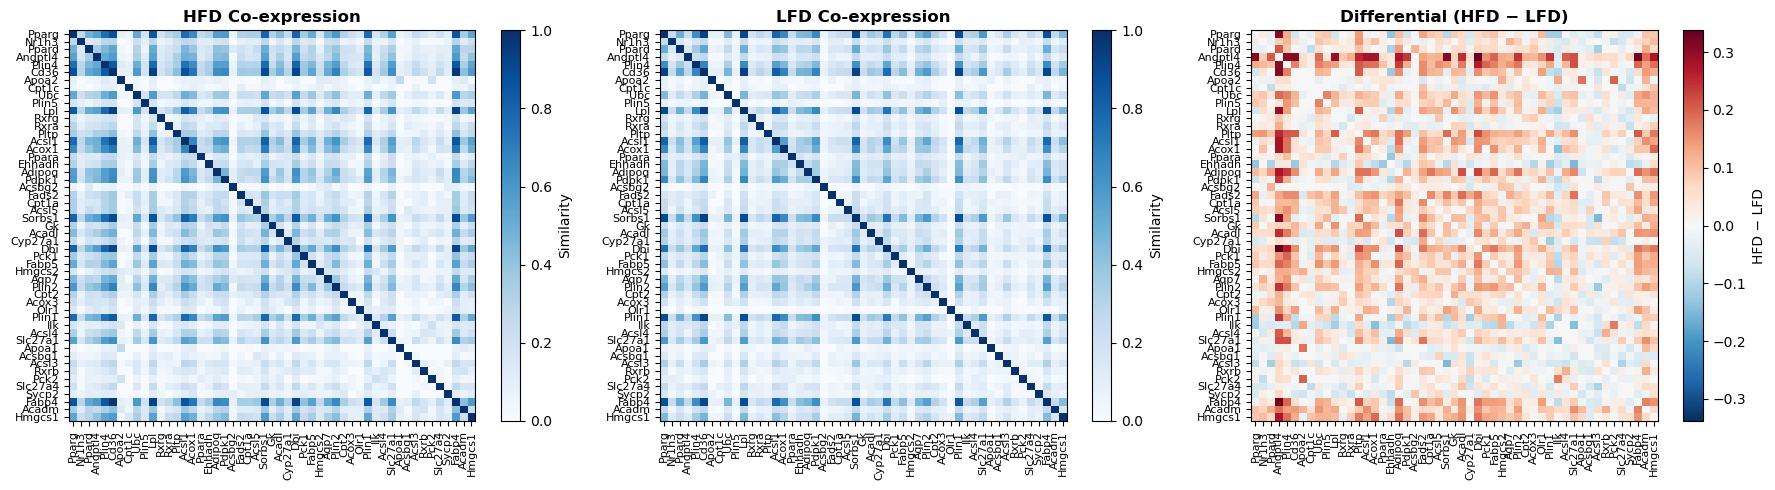

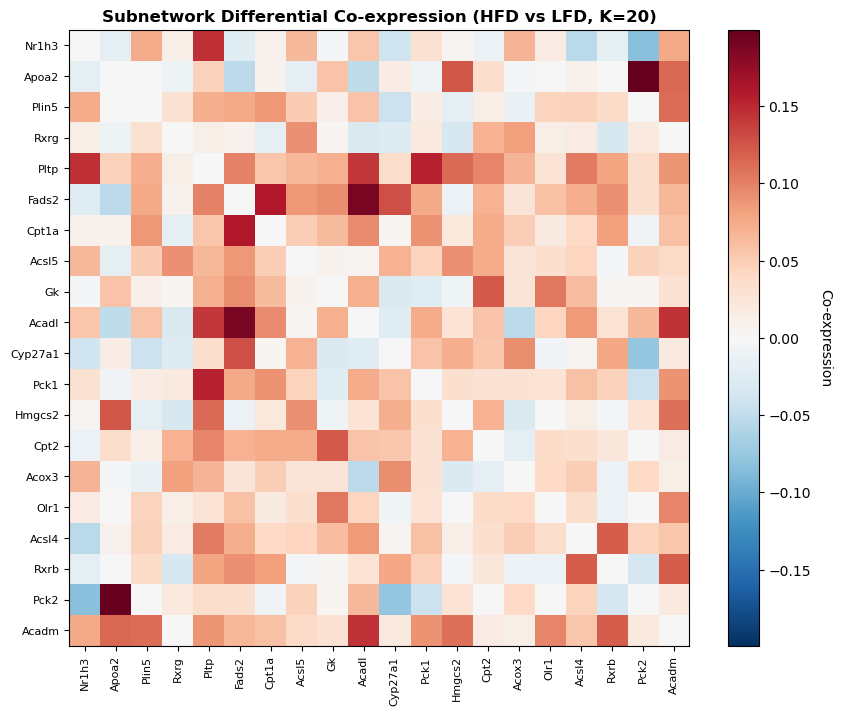

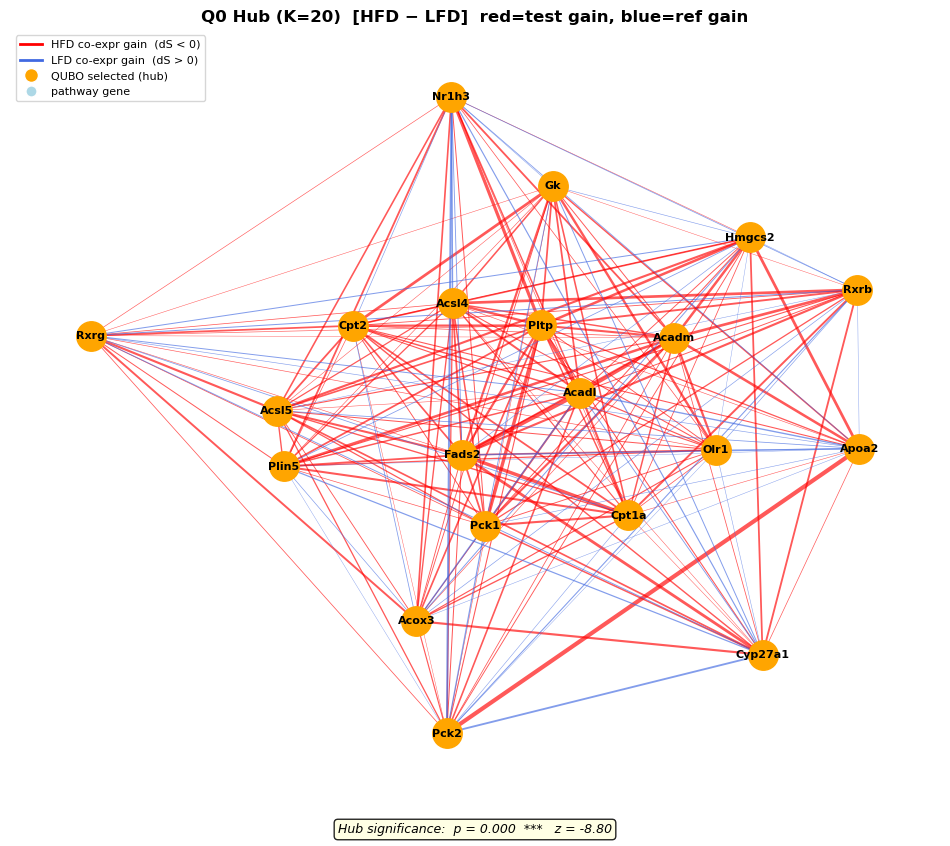

In [21]:
# ── Run DR-QUBO — Kong2023 CD — Wnt signaling ─────────────────────────────
results_cd = run_pipeline(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = test_label,      # condition A
    reference_label = reference_label,      # condition B (reference)
    pathway_name    = pathway_target,
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    num_reads       = 1000,
    solver          = 'sd',
    plotit          = True,
    outfile         = 'qubo_genes_pparg.txt',
)

print(f"\n── Selected pathway {pathway_target} subnetwork ──")
print(results_cd['sub_g_net'])

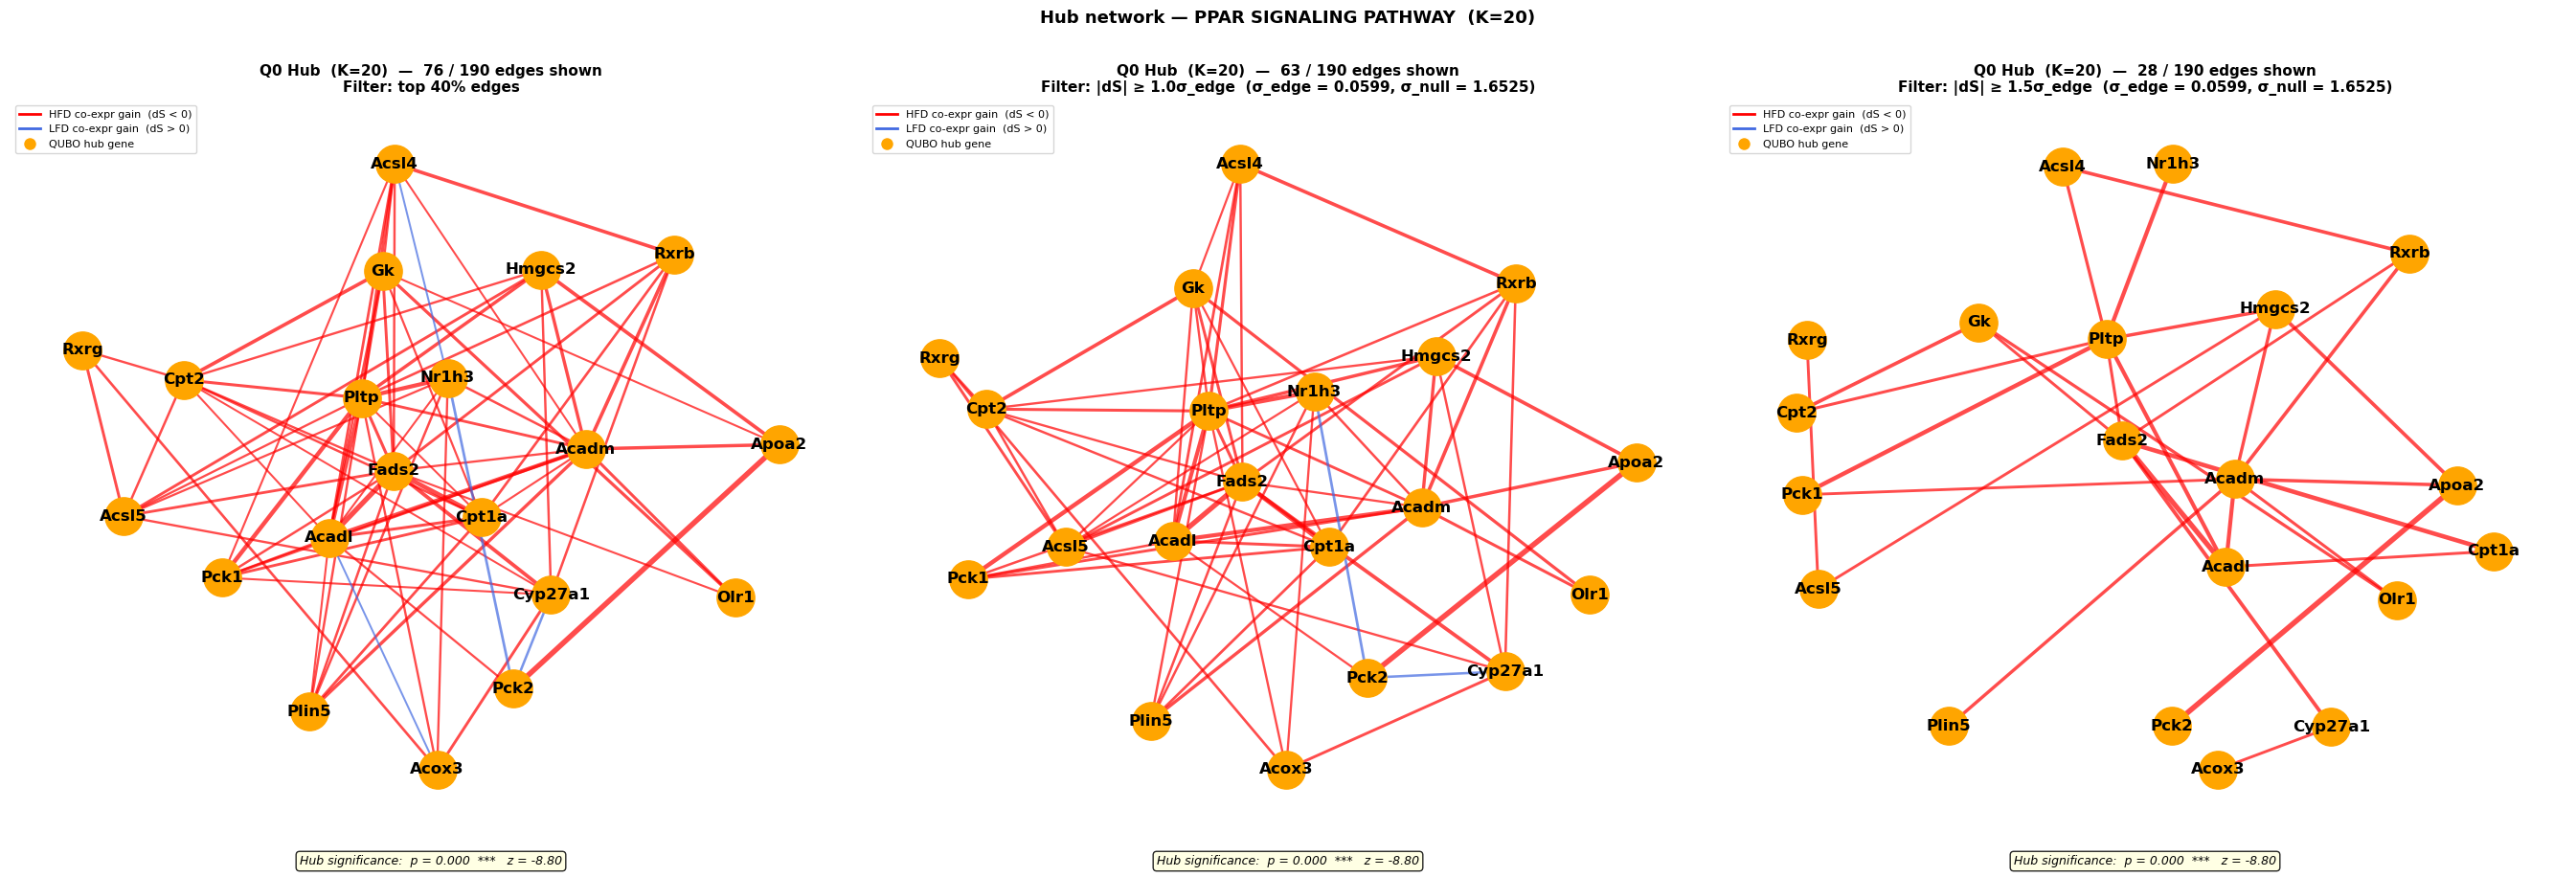

In [22]:
from qubo_dr.plot import plot_hub_network
import matplotlib.pyplot as plt
K = 20
REFERENCE_LABEL = reference_label   # condition B (reference)
TEST_LABEL = test_label
PATHWAY_NAME = pathway_target
# ── Three panels: coarse → stat-informed → fine ──────────────────────────────
#fig, axes = plt.subplots(3, 1, figsize=(10, 15))
fig, axes = plt.subplots(1, 3, figsize=(27, 9))

# Panel 1 — top 40 % of hub edges (quick overview)
plot_hub_network(
    results_cd, top_pct=40,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[0]
)

# Panel 2 — statistically principled: edges above 1 null-noise σ
#   σ_edge = std(E_null) / (2 × √(K×(K−1)/2))
#   Requires run_perm_test=True in run_pipeline() (already done above)
plot_hub_network(
    results_cd, n_sigma=1.0,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[1]
)

# Panel 3 — stricter: 1.5 σ (fewer, strongest edges only)
plot_hub_network(
    results_cd, n_sigma=1.5,
    test_label=TEST_LABEL, reference_label=REFERENCE_LABEL,
    ax=axes[2]
)

plt.suptitle(f'Hub network — {PATHWAY_NAME}  (K={K})',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


Fetching pathway 'PPAR SIGNALING PATHWAY' [KEGG_2026]
  Found 'PPAR SIGNALING PATHWAY'
  Library: [KEGG_2026]  |  Genes: 76
Classical baseline  |  method='rowsum'  |  K=20
Pathway genes in data: 51/76
Partitioning: 'HFD' (A) vs 'LFD' (B)
  A: 641 cells | B: 1899 cells
  Selected 20 genes (target K=20)
  Genes: ['Angptl4', 'Plin4', 'Cd36', 'Ubc', 'Lpl', 'Pltp', 'Acsl1', 'Acox1', 'Adipoq', 'Fads2', 'Acsl5', 'Sorbs1', 'Acadl', 'Dbi', 'Fabp5', 'Plin2', 'Slc27a1', 'Fabp4', 'Acadm', 'Hmgcs1']
  Saved 20 genes to classical_pathway_genes.txt
Hub significance test (200 permutations)...
  Hub permutation test: 200 perms, K=20 genes, N=2540 cells…
  E_real=-51.3633  null: mean=-0.1483, std=2.7274
  z=-18.78  p=0.0000  ***
Generating plots...
Classical pipeline complete.
QUBO only    (15): ['Acox3', 'Acsl4', 'Apoa2', 'Cpt1a', 'Cpt2', 'Cyp27a1', 'Gk', 'Hmgcs2', 'Nr1h3', 'Olr1', 'Pck1', 'Pck2', 'Plin5', 'Rxrb', 'Rxrg']
Classical only (15): ['Acox1', 'Acsl1', 'Adipoq', 'Angptl4', 'Cd36', 'Dbi', 'Fabp

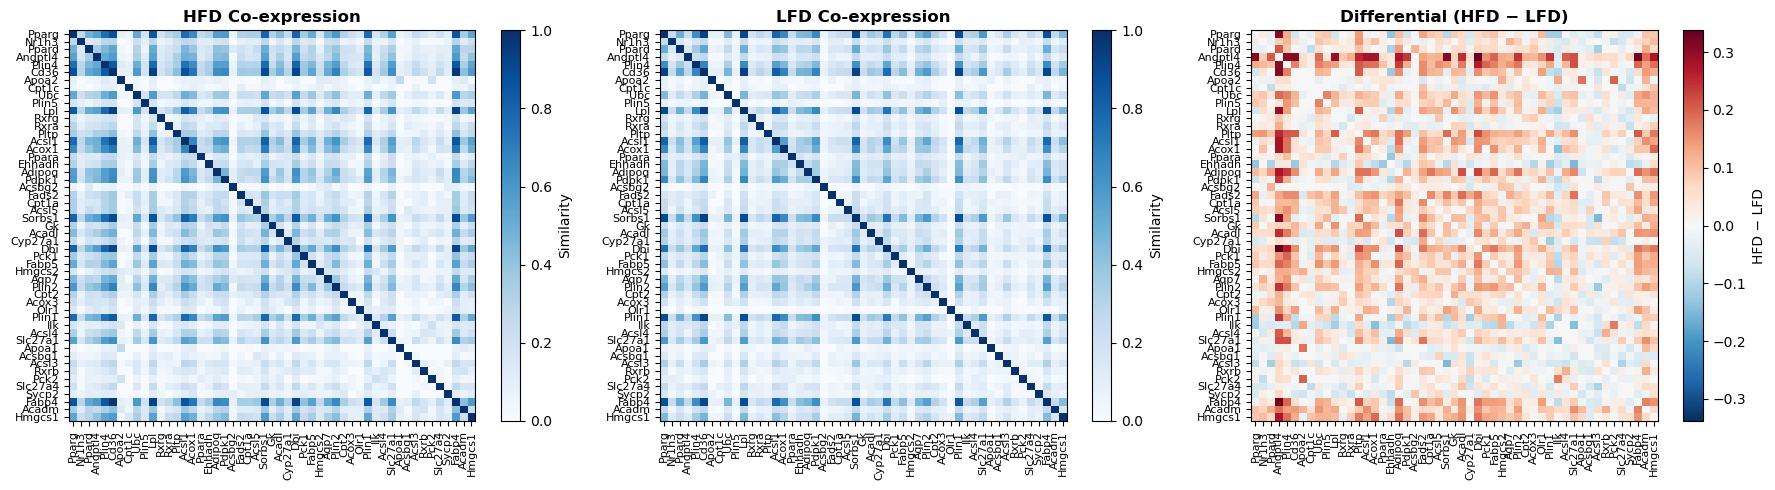

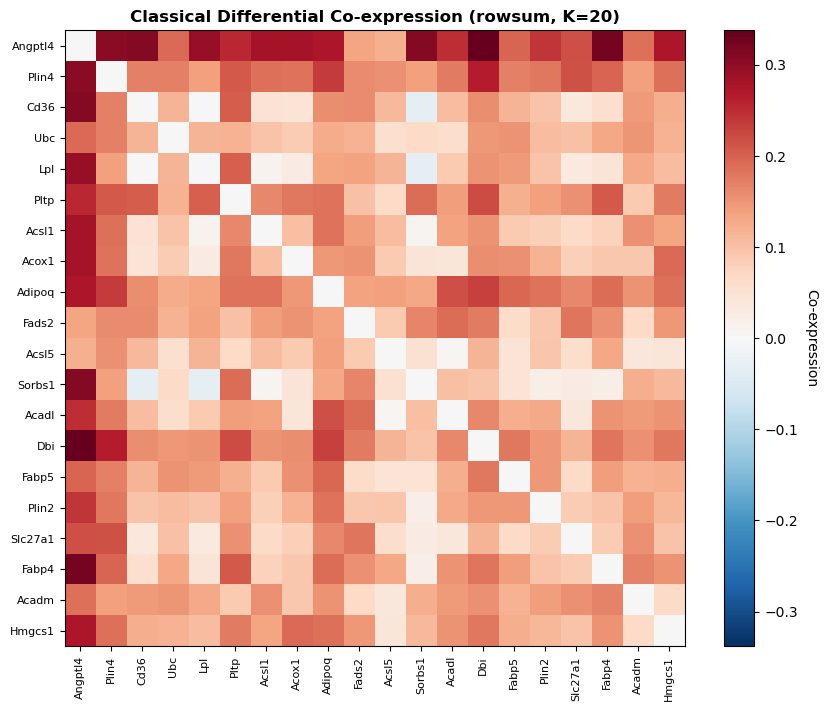

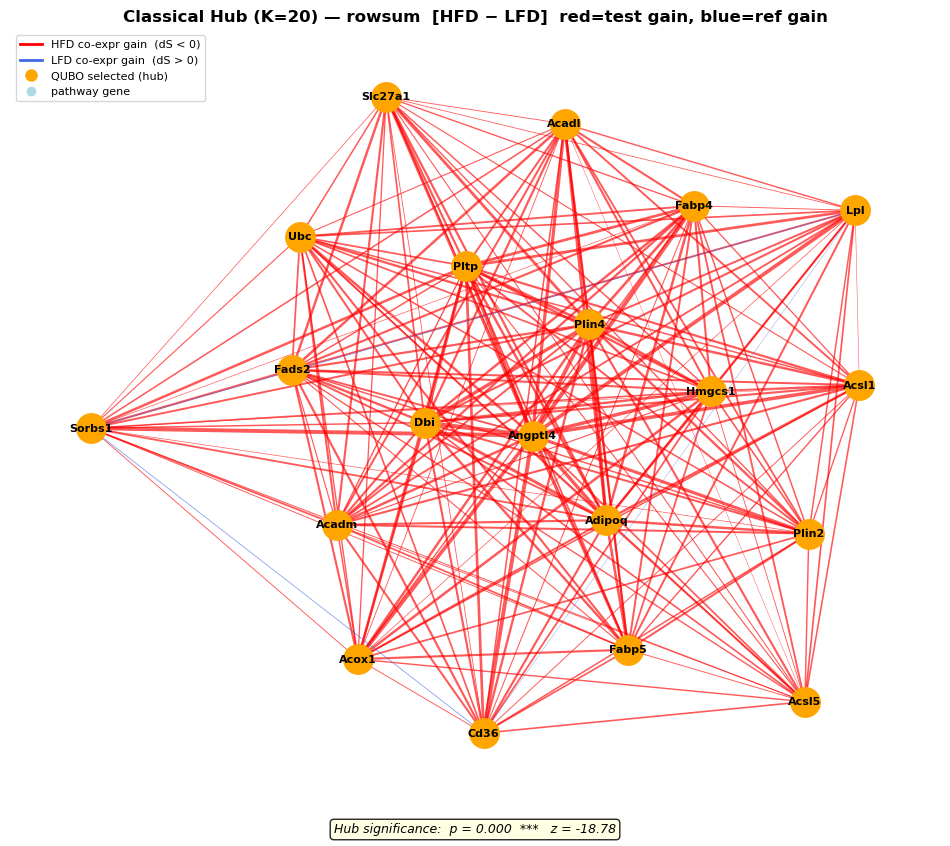

In [24]:
from qubo_dr.pipeline import run_pipeline_classical

# ── Classical baseline — same data, no QUBO ───────────────────────────────
results_cd_classical = run_pipeline_classical(
    X               = X_cd,
    g               = g_cd,
    batch_id        = batch_cd,
    test_label      = test_label,      # condition A
    reference_label = reference_label,      # condition B (reference)
    pathway_name    = pathway_target,
    library         = 'KEGG_2026',    # optional: restricts search to one library (faster)
    K               = 20,
    method          = 'rowsum',     # or 'absrowsum' or 'spectral'
    plotit          = True,
    outfile         = 'classical_pathway_genes.txt',
)

# ── Direct comparison ─────────────────────────────────────────────────────
qubo_genes      = set(results_cd['sub_g_net'])
classical_genes = set(results_cd_classical['sub_g_net'])

print(f"QUBO only    ({len(qubo_genes - classical_genes)}): {sorted(qubo_genes - classical_genes)}")
print(f"Classical only ({len(classical_genes - qubo_genes)}): {sorted(classical_genes - qubo_genes)}")
print(f"Shared       ({len(qubo_genes & classical_genes)}): {sorted(qubo_genes & classical_genes)}")